In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Part 1 — The Business Problem

In [1]:
df = pd.read_csv("Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

NameError: name 'pd' is not defined

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Part 2 — Exploring the Dataset Structure

In [4]:
## Task # 04 
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
# Task # 06:
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [8]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [9]:
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

Part 3 — Investigating Data Quality

In [10]:
# Task # 07:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
(df.isnull().mean()*100)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [12]:
# Task # 08:
df.duplicated().sum()

np.int64(0)

In [13]:
df["customerID"].duplicated().sum()

np.int64(0)

In [14]:
# Task # 09:

df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [15]:
df["TotalCharges"].dtype

dtype('O')

In [16]:
df["TotalCharges"].value_counts().tail(20)

TotalCharges
1185       1
1838.15    1
1263.9     1
2447.45    1
1140.05    1
5064.45    1
2065.15    1
3838.2     1
168.9      1
7843.55    1
3306.85    1
424.75     1
6565.85    1
2117.2     1
203.95     1
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, dtype: int64

In [17]:
df[df['TotalCharges'].str.strip() == ''].shape

(11, 21)

In [18]:
df[df['TotalCharges'].str.strip() == ''].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


Part 4 — Data Cleaning Decisions

In [20]:
# Task # 11
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

In [21]:
df["TotalCharges"].dtype

dtype('float64')

In [22]:
# Checking missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [23]:
# Handling missing values
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [24]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
df["TotalCharges"].dtype

dtype('float64')

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df["customerID"].duplicated().sum()

np.int64(0)

In [28]:
# Creating cleaned Data Frame
clean_df = df.copy()

In [29]:
clean_df = clean_df.drop(columns = ["customerID"])

Part 5 — Univariate EDA

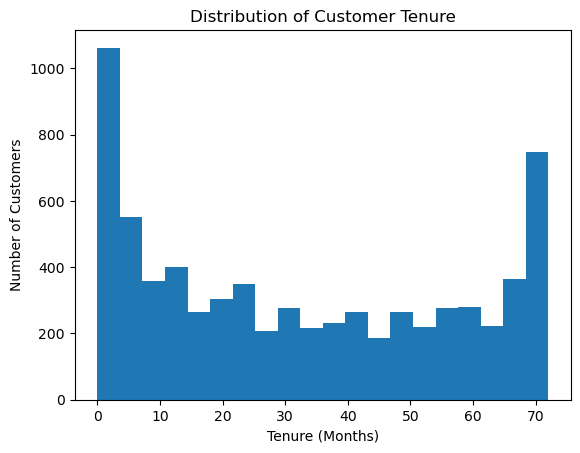

In [30]:
# Task # 12

# Numerical Feature — tenure
clean_df["tenure"].plot(kind = "hist", bins = 20)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

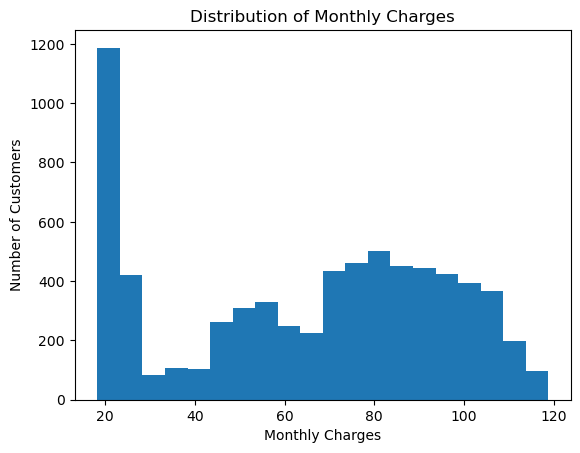

In [31]:
# Numerical Feature — MonthlyCharges
clean_df["MonthlyCharges"].plot(kind = "hist", bins = 20)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

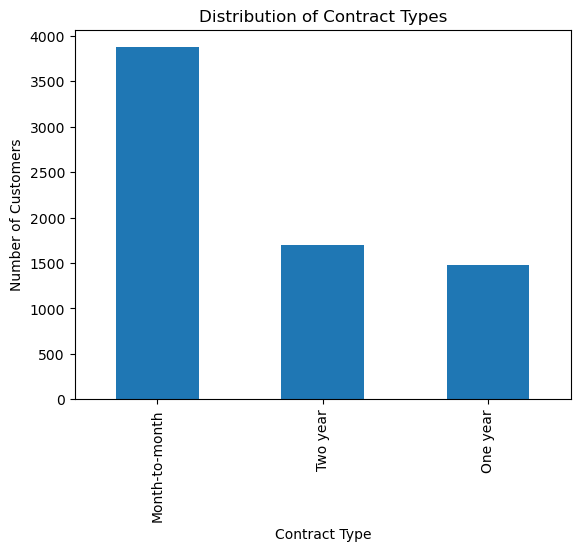

In [34]:
# Categorical Feature — Contract
clean_df["Contract"].value_counts().plot(kind = "bar")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Distribution of Contract Types")
plt.show()

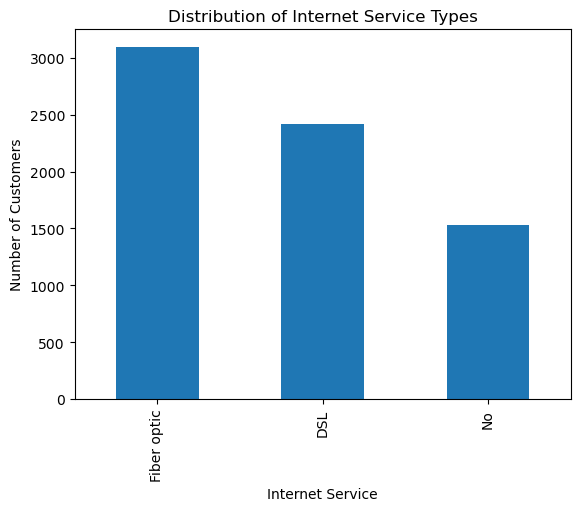

In [35]:
# Categorical Feature — InternetService
clean_df["InternetService"].value_counts().plot(kind = "bar")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Distribution of Internet Service Types")
plt.show()

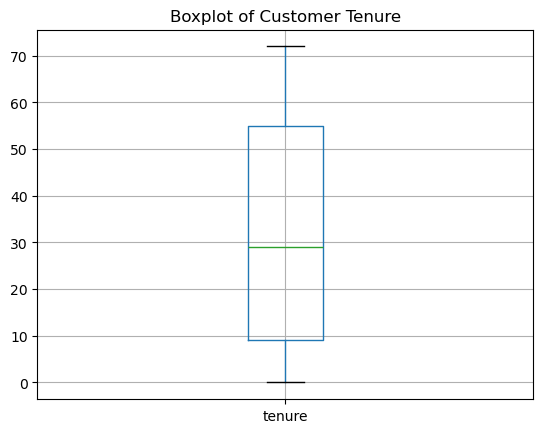

In [37]:
# Task # 13 --- Boxplot for outliers
clean_df.boxplot(column = "tenure")
plt.title("Boxplot of Customer Tenure")
plt.show()

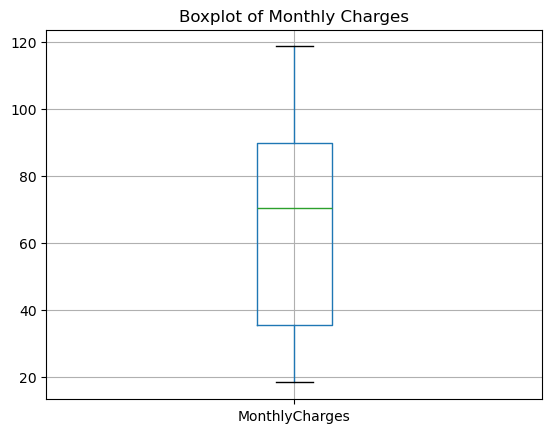

In [38]:
clean_df.boxplot(column = "MonthlyCharges")
plt.title("Boxplot of Monthly Charges")
plt.show()

Part 6 — Target Variable Analysis

In [39]:
# Task # 14

clean_df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [40]:
clean_df["Churn"].value_counts(normalize = True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Part 7 — Bivariate Analysis: Features vs. Churn

In [46]:
# Task # 16: Categorical Features vs. Churn

# Contract vs Churn
contract_churn = pd.crosstab(
    clean_df["Contract"], clean_df["Churn"], normalize = "index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


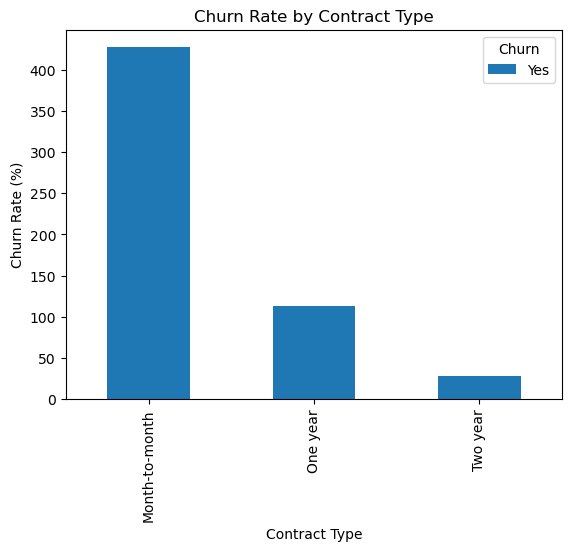

In [42]:
contract_churn[["Yes"]].plot(kind = "bar")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.legend(title = "Churn")
plt.show()

In [44]:
# InternetService vs Churn

internet_churn = pd.crosstab(
    clean_df["InternetService"], clean_df["Churn"], normalize = "index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


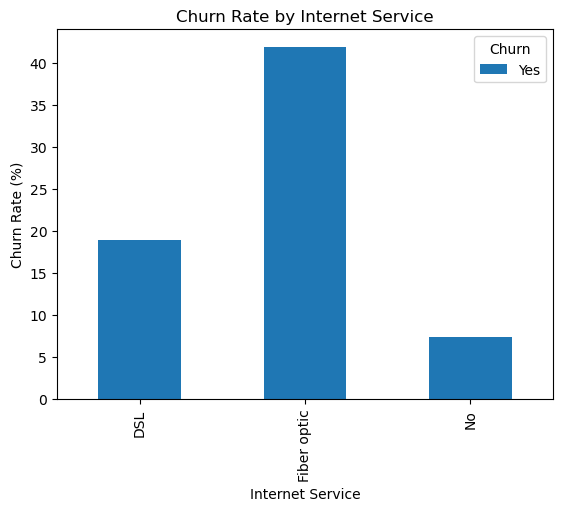

In [45]:
internet_churn[["Yes"]].plot(kind = "bar")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Internet Service")
plt.legend(title = "Churn")
plt.show()

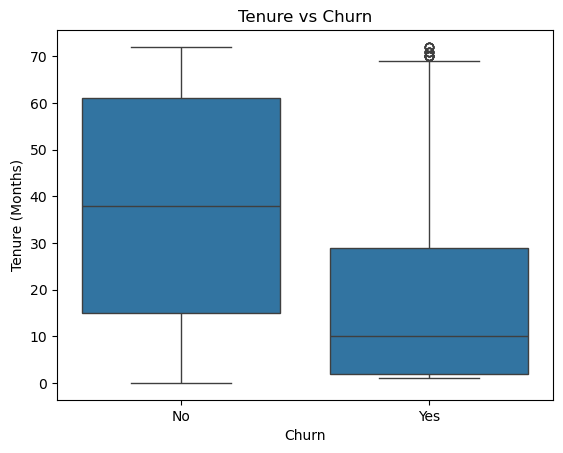

In [54]:
# Task # 17 --- Numerical Features vs. Churn

sns.boxplot(
    x = "Churn", y = "tenure", data = clean_df
)

plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.title("Tenure vs Churn")
plt.show()

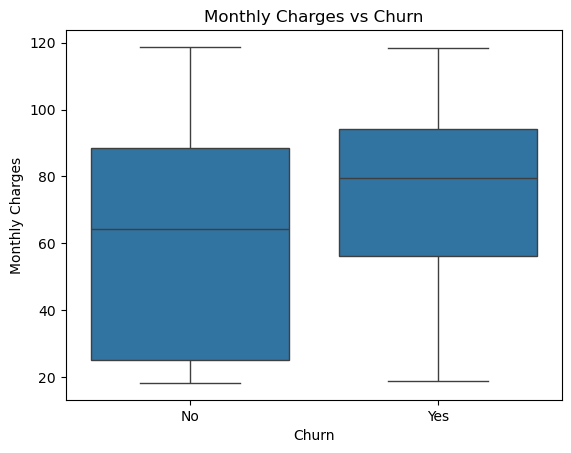

In [53]:
sns.boxplot(
    x = "Churn", y = "MonthlyCharges", data = clean_df
)

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges vs Churn")
plt.show()

Part 8 — Correlation & Feature Relationships

In [55]:
# Task # 18

corr_matrix = clean_df.corr(numeric_only = True)
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


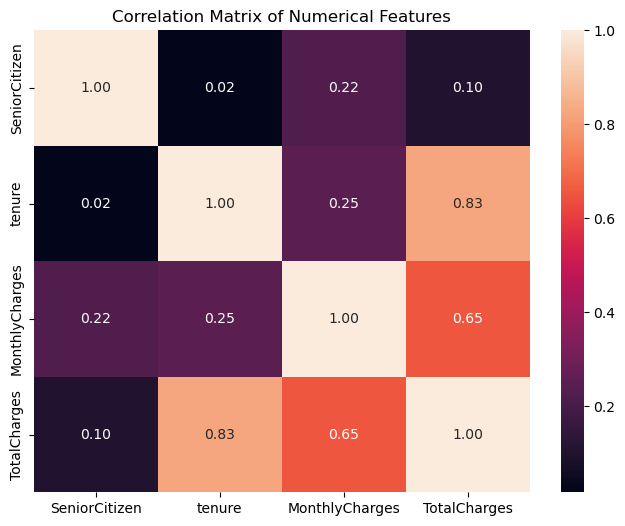

In [56]:
plt.figure(figsize = (8, 6))
sns.heatmap(
    corr_matrix, annot = True, fmt = ".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [58]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
)

strong_pairs = (
    upper.stack().sort_values(key = abs, ascending = False)
)

strong_pairs.head(10)

tenure          TotalCharges      0.826178
MonthlyCharges  TotalCharges      0.651174
tenure          MonthlyCharges    0.247900
SeniorCitizen   MonthlyCharges    0.220173
                TotalCharges      0.103006
                tenure            0.016567
dtype: float64

Part 9 — Data Leakage Awareness

Part 10 — ML-Readiness Checklist

In [59]:
# Task 23 --- Final Cleaned Data frame

clean_df = df.copy()

clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"], errors = "coerce"
)

clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(0)

clean_df = clean_df.drop(columns = ["customerID"])

clean_df = clean_df.drop_duplicates()

In [60]:
clean_df.to_csv("clean_churn.csv", index = False)

In [61]:
# Task # 24 --- Final Verification

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [62]:
clean_df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [63]:
clean_df.duplicated().sum()

np.int64(0)

In [64]:
clean_df["TotalCharges"].dtype

dtype('float64')

In [65]:
clean_df.shape

(7021, 20)

Part 12 — Key Findings & Final Reflection

Final Reflection